In [1]:
import os
import pandas as pd
import kagglehub

# 1. Descargar el dataset
path = kagglehub.dataset_download("kingabzpro/zombies-apocalypse")

print("Path to dataset files:", path)

# 2. Listar los ficheros en el directorio
files = os.listdir(path)
print("Ficheros encontrados:", files)

# 3. Leer el archivo CSV
# Suponiendo que el archivo se llama 'zombies-apocalypse.csv' o similar.
# Ajusta el nombre del archivo si es distinto según lo que imprimió el paso anterior.
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)

# 4. Mostrar las primeras filas para confirmar
print("\nPrimeras 5 filas del dataset:")
print(df.head())

/home/josema/Proyectos/Bootcamp_IA/pildoras/Zombies/MLOps-Zombie-Recognition/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/josema/.cache/kagglehub/datasets/kingabzpro/zombies-apocalypse/versions/1
Ficheros encontrados: ['zombies.csv']

Primeras 5 filas del dataset:
   zombieid zombie  age     sex rurality  household  water  food  medication  \
0         1  Human   18  Female    Rural          1      0  Food  Medication   
1         2  Human   18    Male    Rural          3     24  Food  Medication   
2         3  Human   18    Male    Rural          4     16  Food  Medication   
3         4  Human   19    Male    Rural          1      0  Food  Medication   
4         5  Human   19    Male    Urban          1      0  Food  Medication   

      tools               firstaid  sanitation  clothing documents  
0  No tools     First aid supplies  Sanitation  Clothing       NaN  
1     tools     First aid supplies  Sanitation  Clothing       NaN  
2  No tools     First aid supplies  Sanitation  Clothing       NaN  
3     tools  No first aid supplies  Sanitation  Clothing       NaN  
4 

In [2]:
for col in df.columns:
    print(f"\n{'='*10} Análisis de: {col} ({df[col].dtype}) {'='*10}")
    
    # Si es numérica (int o float)
    if pd.api.types.is_numeric_dtype(df[col]):
        print(df[col].describe())
        
    # Si es categórica u objeto
    else:
        print(df[col].value_counts())
        
    # Siempre verificamos nulos
    nulos = df[col].isnull().sum()
    if nulos > 0:
        print(f"--> ¡Alerta! Valores faltantes: {nulos}")


========== Análisis de: zombieid (int64) ==========
count    200.000000
mean     100.500000
std       57.879185
min        1.000000
25%       50.750000
50%      100.500000
75%      150.250000
max      200.000000
Name: zombieid, dtype: float64

========== Análisis de: zombie (object) ==========
zombie
Human     121
Zombie     79
Name: count, dtype: int64

========== Análisis de: age (int64) ==========
count    200.000000
mean      44.415000
std       17.371865
min       18.000000
25%       29.000000
50%       42.000000
75%       58.000000
max       85.000000
Name: age, dtype: float64

========== Análisis de: sex (object) ==========
sex
Male      101
Female     99
Name: count, dtype: int64

========== Análisis de: rurality (object) ==========
rurality
Rural       98
Urban       54
Suburban    48
Name: count, dtype: int64

========== Análisis de: household (int64) ==========
count    200.000000
mean       2.680000
std        1.263162
min        1.000000
25%        2.000000
50%        2.5

In [3]:
# 1. Rellenar los nulos asumiendo que NaN = "No tiene"
df['clothing'] = df['clothing'].fillna('No clothing')
df['documents'] = df['documents'].fillna('No documents')

# 2. Convertir columnas categóricas a binarias (0 y 1)
# Esto es vital porque los modelos de ML no entienden texto como "Food" o "No food"
cols_to_binarize = ['food', 'medication', 'tools', 'firstaid', 'sanitation', 'clothing', 'documents']

for col in cols_to_binarize:
    # Creamos una regla: Si el valor contiene la palabra clave, es 1, si no, 0
    # Ajusta la lógica según el valor específico (ej. 'Food' vs 'No food')
    df[col] = df[col].apply(lambda x: 1 if 'No' not in str(x) else 0)

# 3. Encoding de variables categóricas nominales (como 'sex' y 'rurality')
df = pd.get_dummies(df, columns=['sex', 'rurality'], drop_first=True)

# 4. Transformar el target 'zombie' a numérico
df['zombie'] = df['zombie'].apply(lambda x: 1 if x == 'Zombie' else 0)

# Limpieza final: eliminar la columna ID, no aporta valor al modelo
df = df.drop(columns=['zombieid'])

In [4]:
import pandas as pd
import mlflow
import mlflow.sklearn
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

2026/07/15 12:58:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- Resultados del Entrenamiento ---
Media de Validación Cruzada: 0.70
Accuracy en Test final: 0.88

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        23
           1       0.83      0.88      0.86        17

    accuracy                           0.88        40
   macro avg       0.87      0.88      0.87        40
weighted avg       0.88      0.88      0.88        40



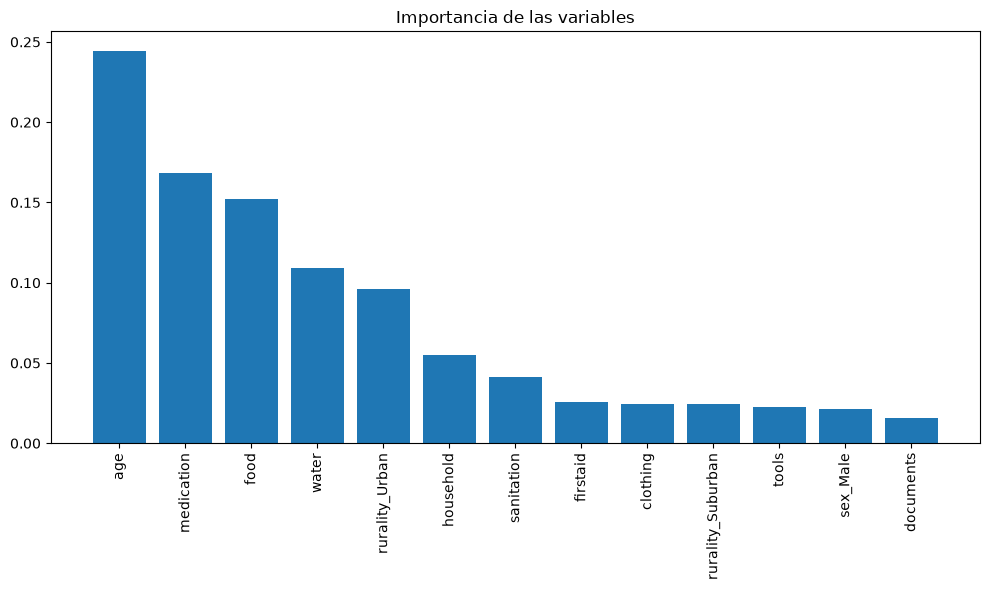

In [5]:
# 1. Separar Features (X) y Target (y)

X = df.drop(columns=['zombie'])
X = X.astype(int)
y = df['zombie']

# 2. Dividir en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Iniciar experimento en MLflow
mlflow.set_experiment("Zombie_Apocalypse_Model")

with mlflow.start_run():
    # Definir hiperparámetros del modelo
    params = {
        "n_estimators": 100, 
        "max_depth": 5, 
        "class_weight": "balanced",
        "random_state": 42
    }
    
    # Crear y entrenar modelo
    clf = RandomForestClassifier(**params)
    clf.fit(X_train, y_train)
    
    # Realizar Validación Cruzada para medir estabilidad (CV=5)
    cv_scores = cross_val_score(clf, X, y, cv=5)
    
    # Evaluar en el set de prueba (Test)
    predictions = clf.predict(X_test)
    test_acc = accuracy_score(y_test, predictions)
    
    # 4. Registrar métricas y modelo en MLflow
    mlflow.log_params(params)
    mlflow.log_metric("cv_mean_accuracy", np.mean(cv_scores))
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.sklearn.log_model(clf, "model")
    
    # Resultados en consola
    print(f"--- Resultados del Entrenamiento ---")
    print(f"Media de Validación Cruzada: {np.mean(cv_scores):.2f}")
    print(f"Accuracy en Test final: {test_acc:.2f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, predictions))

    

    importances = clf.feature_importances_
    feature_names = X.columns
    indices = np.argsort(importances)[::-1]

    # Graficar
    plt.figure(figsize=(10, 6))
    plt.title("Importancia de las variables")
    plt.bar(range(X.shape[1]), importances[indices], align="center")
    plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=90)
    plt.tight_layout()
    plt.show()

In [6]:
# 1. Crear un registro nuevo (un superviviente ficticio)
nuevo_superviviente = pd.DataFrame({
    'age': [30],
    'household': [2],
    'water': [10],
    'food': [1],
    'medication': [0],
    'tools': [1],
    'firstaid': [1],
    'sanitation': [0],
    'clothing': [1],
    'documents': [0],
    'sex_Male': [1],
    'rurality_Suburban': [0],
    'rurality_Urban': [1]
})

# 2. Aseguramos que los tipos sean int, igual que en el entrenamiento
nuevo_superviviente = nuevo_superviviente.astype(int)

# 3. Realizar la predicción
prediccion = clf.predict(nuevo_superviviente)
probabilidad = clf.predict_proba(nuevo_superviviente)

# 4. Interpretar el resultado
estado = "Zombie" if prediccion[0] == 1 else "Humano"
print(f"El modelo predice que el individuo es: {estado}")
print(f"Probabilidad: {probabilidad[0][1]*100:.2f}% de ser Zombie")

El modelo predice que el individuo es: Zombie
Probabilidad: 50.98% de ser Zombie


In [ ]:
# pero habria que hacerlo estilo pipeline que esta parte falta mejorar ni esta probada

# 1. CARGA Y PREPROCESAMIENTO
df['zombie'] = df['zombie'].apply(lambda x: 1 if x == 'Zombie' else 0)

# Definir las columnas
target = 'zombie'
features = df.drop(columns=[target])

# Lógica personalizada para convertir texto a binario (nuestra regla de negocio)
def binarize_cols(X):
    X = X.copy()
    for col in X.columns:
        if X[col].dtype == 'object':
            X[col] = X[col].apply(lambda x: 1 if 'No' not in str(x) else 0)
    return X

# 2. CREACIÓN DEL PIPELINE
# El pipeline encadena: limpieza -> binarización -> modelo
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='No')),
    ('binarizer', FunctionTransformer(binarize_cols)),
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))
])

# 3. DIVISIÓN DE DATOS
X_train, X_test, y_train, y_test = train_test_split(features, df[target], test_size=0.2, random_state=42)

# 4. ENTRENAMIENTO Y MLOPS (MLFLOW)
mlflow.set_experiment("Zombie_Apocalypse_Model")

with mlflow.start_run():
    # Entrenamiento
    model.fit(X_train, y_train)
    
    # Validación Cruzada
    cv_scores = cross_val_score(model, features, df[target], cv=5)
    
    # Evaluación en Test
    predictions = model.predict(X_test)
    test_acc = accuracy_score(y_test, predictions)
    
    # Logueo de métricas
    mlflow.log_metric("cv_mean_accuracy", np.mean(cv_scores))
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.sklearn.log_model(model, "model")
    
    print(f"Pipeline entrenado. Accuracy en Test: {test_acc:.2f}")
    print(classification_report(y_test, predictions))
    

ValueError: fill_value='No' (of type <class 'str'>) cannot be cast to the input data that is dtype('int64'). If fill_value is a Python scalar, instead pass  a numpy scalar (e.g. fill_value=np.uint8(0) if your data is of type np.uint8). Make sure that both dtypes are of the same kind.

In [32]:
print("Tipo de datos en X:")
print(X.dtypes)

print("\n¿Hay algún valor nulo en X?")
print(X.isnull().sum().sum())

print("\nPrimeras 3 filas de X:")
print(X.head(3))

Tipo de datos en X:
age                  int64
household            int64
water                int64
food                 int64
medication           int64
tools                int64
firstaid             int64
sanitation           int64
clothing             int64
documents            int64
sex_Male              bool
rurality_Suburban     bool
rurality_Urban        bool
dtype: object

¿Hay algún valor nulo en X?
0

Primeras 3 filas de X:
   age  household  water  food  medication  tools  firstaid  sanitation  \
0   18          1      0     1           1      0         1           1   
1   18          3     24     1           1      1         1           1   
2   18          4     16     1           1      0         1           1   

   clothing  documents  sex_Male  rurality_Suburban  rurality_Urban  
0         1          0     False              False           False  
1         1          0      True              False           False  
2         1          0      True              Fal